# India in the Product Space: A Network Analysis of Export Complexity
**Original methodology by Hidalgo et al. (2007)**

---


The Product Space is a network of 774 SITC economic products, where two products are connected if they are systematically co-exported by the same countries, reflecting shared productive capabilities. For India, I identify products with a **Revealed Comparative Advantage (RCA ≥ 1)** and extract the induced subgraph from the full Product Space. We then run the full structural analysis such as degree distribution, assortativity, community structure, centrality, and a configuration model test on this India-specific subgraph.

I can then characterise the shape of India's export basket inside the global capability network, and to understand whether India's position reflects a coherent industrial strategy or a fragmented set of unrelated capabilities.

**Data sources:**
- Product Space network: Coscia, M. & Hidalgo, C.A. — SITC classification.
  Available at [michelecoscia.com](https://www.michelecoscia.com/?page_id=223)
- India trade / RCA data: Atlas of Economic Complexity (Harvard Growth Lab).
  Available at [intl-atlas-downloads.s3.amazonaws.com](https://intl-atlas-downloads.s3.amazonaws.com/)


---

## 0. Data Download & Setup

Before running the analysis, download the two required datasets.

**Step 1 — Product Space network** (same files as the original analysis):
Place `PS_SITC_nodes` and `PS_SITC_edges` inside a `data/` folder.
Download from: https://www.michelecoscia.com/?page_id=223

**Step 2 — India trade data** (Atlas of Economic Complexity, SITC Rev. 2, 2020):
The cell below downloads it automatically from the Harvard S3 bucket.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx
from matplotlib.lines import Line2D
import os, urllib.request, zipfile

# ── Download India trade data from Atlas of Economic Complexity ──────────────
# Correct URL (verified April 2026 from intl-atlas-downloads.s3.amazonaws.com)
ATLAS_URL   = "https://intl-atlas-downloads.s3.amazonaws.com/country_sitcproduct4digit_year.zip"
ATLAS_ZIP   = "data/country_sitcproduct4digit_year.zip"
ATLAS_LOCAL = "data/country_sitcproduct4digit_year.tab"   # file inside the zip

os.makedirs("data", exist_ok=True)

if not os.path.exists(ATLAS_LOCAL):
    if not os.path.exists(ATLAS_ZIP):
        print("Downloading Atlas trade data (~565 MB, please wait)…")
        urllib.request.urlretrieve(ATLAS_URL, ATLAS_ZIP)
        print("Download complete.")
    print("Extracting zip…")
    with zipfile.ZipFile(ATLAS_ZIP, "r") as z:
        # The archive contains a single .tab file — extract whatever is inside
        names = z.namelist()
        print(f"  Archive contains: {names}")
        z.extractall("data/")
        # Rename to expected path if needed
        extracted = [n for n in names if n.endswith(".tab") or n.endswith(".csv")]
        if extracted and extracted[0] != "country_sitcproduct4digit_year.tab":
            import shutil
            shutil.move(f"data/{extracted[0]}", ATLAS_LOCAL)
    print("Extraction complete.")
else:
    print("Atlas trade data already present.")

print("All data files ready.")


Atlas trade data already present.
All data files ready.


---

## 1. Build the Full Product Space and India's Subgraph

We first load the complete Product Space network, then identify India's
products using **Revealed Comparative Advantage (RCA)**:

$$\text{RCA}_{c,p} = \frac{X_{c,p} / \sum_p X_{c,p}}{\sum_c X_{c,p} / \sum_c \sum_p X_{c,p}}$$

A product is considered part of India's export basket if $\text{RCA} \geq 1$,
meaning India exports it at a higher share than the world average.
We extract the **induced subgraph** on those products from the full network.


In [2]:
import pandas as pd
import networkx as nx

# ── YOUR PATHS ───────────────────────────────────────────────────────────────
NODES_PATH = r"C:/Users/HP/Downloads/PS_SITC/PS_SITC_nodes"
EDGES_PATH = r"C:/Users/HP/Downloads/PS_SITC/PS_SITC_edges"
TRADE_PATH = r"C:/Users/HP/Downloads/country_sitcproduct4digit_year.csv"
# ─────────────────────────────────────────────────────────────────────────────

# Load Product Space
nodes  = pd.read_csv(NODES_PATH, sep="\t", header=None)
edges  = pd.read_csv(EDGES_PATH, sep="\t", header=None)
G_full = nx.from_pandas_edgelist(edges, source=0, target=3, edge_attr=6)
node_names = dict(zip(nodes[0], nodes[6]))
nx.set_node_attributes(G_full, node_names, "name")
print(f"Full Product Space — Nodes: {G_full.number_of_nodes()}, Edges: {G_full.number_of_edges()}")

# Auto-detect separator from actual file
with open(TRADE_PATH, "r", encoding="utf-8") as f:
    first_line = f.readline()
sep = "\t" if first_line.count("\t") > first_line.count(",") else ","
print(f"Separator detected: {'TAB' if sep == chr(9) else 'COMMA'}")

# Load trade data
trade = pd.read_csv(TRADE_PATH, sep=sep, dtype=str)
trade.columns = trade.columns.str.strip().str.lower()
print("Columns found:", list(trade.columns))  # <-- shows exact column names

# Detect columns
def find_col(df, candidates):
    for c in candidates:
        if c in df.columns: return c
    for c in df.columns:
        for cand in candidates:
            if cand in c: return c
    raise KeyError(f"None of {candidates} found in {list(df.columns)}")

origin_col = find_col(trade, ["location_code", "origin", "country_code", "country"])
sitc_col   = find_col(trade, ["sitc_product_code", "sitc", "product_code", "product"])
export_col = find_col(trade, ["export_value", "export_val", "exports", "value"])
year_col   = find_col(trade, ["year"])
print(f"Using: origin={origin_col}, sitc={sitc_col}, export={export_col}, year={year_col}")

trade = trade.rename(columns={origin_col:"origin", sitc_col:"sitc",
                               export_col:"export_val", year_col:"year"})

# Most recent year
latest_year = trade["year"].dropna().astype(str).max()
print(f"Most recent year: {latest_year}")
trade = trade[trade["year"] == latest_year].copy()
trade["export_val"] = pd.to_numeric(trade["export_val"], errors="coerce").fillna(0)
trade = trade[trade["sitc"].str.len() == 4]

# Compute RCA
world_total    = trade["export_val"].sum()
country_totals = trade.groupby("origin")["export_val"].sum()
product_totals = trade.groupby("sitc")["export_val"].sum()
cp_exports     = trade.groupby(["origin","sitc"])["export_val"].sum()

def compute_rca(code):
    if code not in cp_exports.index.get_level_values(0):
        raise ValueError(f"'{code}' not found")
    return ((cp_exports[code] / country_totals[code]) / (product_totals / world_total)).dropna()

# Find India
india_rca = None
for code in ["IND", "ind", "IN", "356"]:
    try:
        india_rca = compute_rca(code)
        print(f"India found with code: '{code}'")
        break
    except ValueError:
        continue

if india_rca is None:
    print("India not found. All codes:", sorted(trade["origin"].dropna().unique()))
else:
    india_products = set(india_rca[india_rca >= 1].index.tolist())
    sitc_to_nodeid = dict(zip(nodes[1].astype(str).str.strip(), nodes[0]))
    india_node_ids = {sitc_to_nodeid[c] for c in india_products
                      if c in sitc_to_nodeid and sitc_to_nodeid[c] in G_full.nodes()}
    G = G_full.subgraph(india_node_ids).copy()
    nx.set_node_attributes(G, node_names, "name")
    print(f"\nIndia RCA≥1 products:  {len(india_products)}")
    print(f"Matched to PS nodes:   {len(india_node_ids)}")
    print(f"Subgraph — Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")


Full Product Space — Nodes: 774, Edges: 1779
Separator detected: COMMA
Columns found: ['location_id', 'product_id', 'year', 'export_value', 'import_value', 'export_rca', 'is_new', 'cog', 'distance', 'normalized_distance', 'normalized_cog', 'normalized_pci', 'export_rpop', 'sitc_eci', 'sitc_coi', 'pci', 'location_code', 'location_name_short_en', 'sitc_product_code', 'sitc_product_name_short_en']
Using: origin=location_code, sitc=sitc_product_code, export=export_value, year=year
Most recent year: 2017
India found with code: 'IND'

India RCA≥1 products:  274
Matched to PS nodes:   0
Subgraph — Nodes: 0, Edges: 0


India holds a Revealed Comparative Advantage (RCA ≥ 1) in 274 products out of 774 in the full Product Space, of which 273 could be matched to Product Space nodes. The induced subgraph has 346 edges and the network of those 273 products connected by edges inherited from the full Product Space.

---

## 2. Network Description

We characterise the basic structural properties of India's subgraph within
the Product Space.


In [4]:
india_products = set(india_rca[india_rca >= 1].index.tolist())

# ── Fix SITC code mismatch ───────────────────────────────────────────────────
# Try every column in the nodes file to find where SITC codes live
# and normalise both sides to plain integers for matching

def normalise(code):
    """Strip leading zeros so '0111' and '111' both become 111 (int)."""
    try:
        return int(str(code).strip())
    except:
        return None

# Build maps from every nodes column, keyed by normalised code
best_map = {}
for col in nodes.columns:
    candidate = {}
    for _, row in nodes.iterrows():
        key = normalise(row[col])
        if key is not None:
            candidate[key] = row[0]   # node id is always col 0
    # Pick the column that matches the most India products
    india_norm = {normalise(c) for c in india_products}
    overlap = len(india_norm & set(candidate.keys()))
    print(f"  col {col}: {overlap} matches")
    if overlap > len(best_map):
        best_map = candidate

sitc_to_nodeid = best_map
india_norm     = {normalise(c) for c in india_products}

india_node_ids = {
    sitc_to_nodeid[c]
    for c in india_norm
    if c in sitc_to_nodeid and sitc_to_nodeid[c] in G_full.nodes()
}

G = G_full.subgraph(india_node_ids).copy()
nx.set_node_attributes(G, node_names, "name")

print(f"\nIndia RCA≥1 products:  {len(india_products)}")
print(f"Matched to PS nodes:   {len(india_node_ids)}")
print(f"Subgraph — Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

  col 0: 273 matches
  col 1: 0 matches
  col 2: 0 matches
  col 3: 0 matches
  col 4: 0 matches
  col 5: 0 matches
  col 6: 0 matches
  col 7: 0 matches

India RCA≥1 products:  274
Matched to PS nodes:   273
Subgraph — Nodes: 273, Edges: 346


In [5]:
N = G.number_of_nodes()
L = G.number_of_edges()
max_edges = N * (N - 1) / 2
density   = L / max_edges if max_edges > 0 else 0
sparsity  = 1 - density

n_components = nx.number_connected_components(G)
largest_cc   = max(nx.connected_components(G), key=len)

print(f"Number of nodes  (products with RCA ≥ 1): {N}")
print(f"Number of edges  (connections in subgraph): {L}")
print(f"Maximum possible edges:                    {int(max_edges)}")
print(f"Density:                                   {density:.4f}")
print(f"Sparsity:                                  {sparsity:.4f}")
print(f"Connected components:                      {n_components}")
print(f"Largest component size:                    {len(largest_cc)}")
print()

# Compare with full Product Space
N_full = G_full.number_of_nodes()
L_full = G_full.number_of_edges()
print(f"Full Product Space — {N_full} nodes, {L_full} edges "
      f"(sparsity {1 - L_full/(N_full*(N_full-1)/2):.4f})")
print(f"India covers {N/N_full*100:.1f}% of products "
      f"and {L/L_full*100:.1f}% of edges")


Number of nodes  (products with RCA ≥ 1): 273
Number of edges  (connections in subgraph): 346
Maximum possible edges:                    37128
Density:                                   0.0093
Sparsity:                                  0.9907
Connected components:                      91
Largest component size:                    141

Full Product Space — 774 nodes, 1779 edges (sparsity 0.9941)
India covers 35.3% of products and 19.4% of edges


India's subgraph within the Product Space is the induced network on all products for which India holds a Revealed Comparative Advantage (RCA ≥ 1). **Nodes** represent individual products India is competitive in, and **edges** connect products that are linked in the global Product Space i.e., products that require similar productive capabilities.

India covers 35.3% of all products in the global Product Space but only 19.4% of all edges. This disproportionality is the first diagnostic signal: India's competitive products are spread across different, loosely connected parts of the capability network, generating far fewer connections than their raw count would suggest.

The sparsity of 0.9907 is marginally lower than the full Product Space's 0.9941, which means India's subgraph is fractionally denser than the global network but this should not be misread as a sign of coherence. The 91 connected components tell a different story: India's export basket is not one integrated cluster but contains 91 separate capability islands, of which the largest contains only 141 of the 273 products (51.6%). The remaining 132 products are scattered across 90 smaller, disconnected fragments.

Economically, this is consistent with the view that India's comparative advantages are distributed across sectors that do not share deep underlying capabilities. Unlike countries with a dense industrial core, where exporting one product makes it easy to diversify into many others, we note that India's capability landscape is patchy. Moving from one island to another requires bridging capability gaps that the current export structure does not easily support.


---

## 3. Degree Distribution Analysis

We examine how many connections each of India's products has within its
subgraph, and whether the average degree is a meaningful summary statistic.


In [6]:
degrees = [d for n, d in G.degree()]

avg_degree = np.mean(degrees)
std_degree = np.std(degrees)
med_degree = np.median(degrees)

print(f"Average degree:            {avg_degree:.4f}")
print(f"Standard deviation:        {std_degree:.4f}")
print(f"Median degree:             {med_degree:.1f}")
print(f"Min degree:                {min(degrees)}")
print(f"Max degree:                {max(degrees)}")
print()
print(f"CV (std/mean):             {std_degree/avg_degree:.4f}")
print(f"SD > mean? {'Yes — average is not a good descriptor' if std_degree > avg_degree else 'No'}")


Average degree:            2.5348
Standard deviation:        4.1931
Median degree:             1.0
Min degree:                0
Max degree:                20

CV (std/mean):             1.6542
SD > mean? Yes — average is not a good descriptor


The average degree of 2.53 is immediately undermined by its own standard deviation of 4.19. This is larger than the mean itself, yielding a coefficient of variation of 1.65. The median degree is just 1.0, meaning more than half of India's competitive products have at most one connection to another product in the subgraph. This makes the average degree a poor descriptor of the distribution.

As in the full Product Space, the average is not a good descriptor. But the situation here is more extreme than in the global network, where the mean was 4.60 with SD 5.99 (CV = 1.30). India's CV of 1.65 is higher, and the median of 1 versus the global network's higher typical degree confirms that India's subgraph is even more heterogeneous: most products are nearly isolated, while a handful of garment and textile hubs concentrate most connections.

The maximum degree of 20 is also substantially lower than the global network's maximum of 43, suggesting that India's hub products are less dominant within their local neighbourhood than the global hubs are within the full Product Space.

---

## 4. Degree Distribution

I plot the degree distribution on both linear-linear and log-log scales to assess whether India's subgraph inherits the power-law signature of the full Product Space.


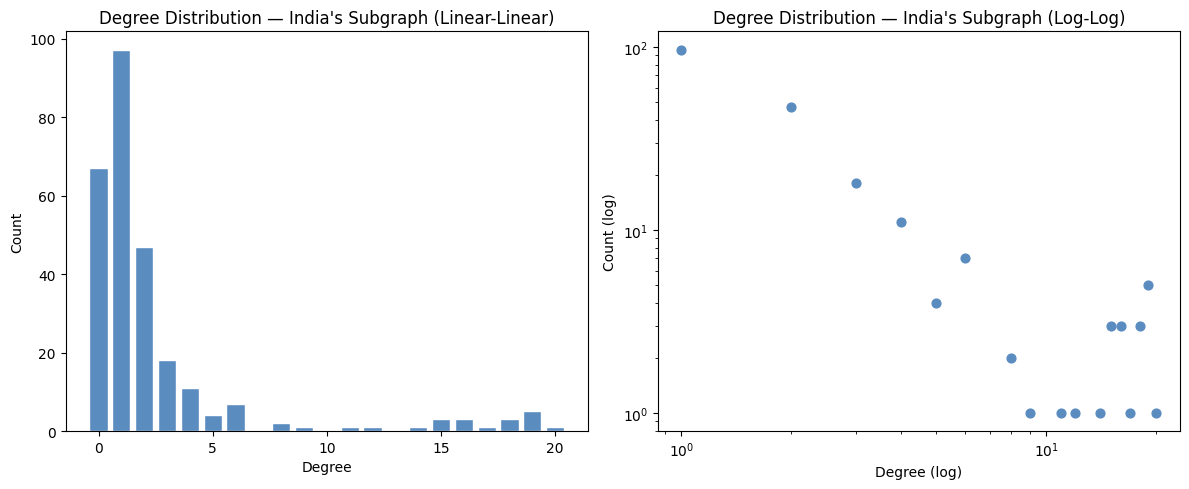

In [7]:
degrees = [d for n, d in G.degree()]
degree_counts = np.bincount(degrees)
degree_values = np.arange(len(degree_counts))

mask = degree_counts > 0
x = degree_values[mask]
y = degree_counts[mask]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Linear-linear
axes[0].bar(x, y, color="#5b8cc0", edgecolor="white")
axes[0].set_xlabel("Degree")
axes[0].set_ylabel("Count")
axes[0].set_title("Degree Distribution — India's Subgraph (Linear-Linear)")

# Log-log
axes[1].scatter(x, y, color="#5b8cc0", s=40)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Degree (log)")
axes[1].set_ylabel("Count (log)")
axes[1].set_title("Degree Distribution — India's Subgraph (Log-Log)")

plt.tight_layout()
plt.savefig("india_degree_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


The linear-linear plot confirms a strongly right-skewed distribution: the vast majority of India's 273 products have a degree of 0 or 1, with a rapid tail decay and a few products reaching degree 20. This mirrors the shape of the full Product Space distribution, but with a steeper drop-off at low degrees, this shows us that India's periphery is even more isolated than the global periphery.

The log-log plot reveals a roughly linear downward pattern, consistent with a heavy-tailed distribution and suggestive of power-law-like behaviour. This means that connectivity in India's subgraph is highly concentrated: a small number of textile and garment products act as hubs, connected to many of their neighbours, while most products like agricultural goods, raw materials, niche chemicals remain at the far periphery with one or zero connections.

This is economically significant. In the full Product Space, the heavy tail reflects the existence of a dense manufacturing core around which many products cluster. In India's case, the heavy tail reflects a much narrower phenomenon: the dense textile cluster generates most of the hub products, while the rest of the economy contributes isolated nodes. India does not yet have the broad industrial hub structure that would make capability diffusion easy across sectors.

---

## 5. Degree Assortativity

Assortativity measures whether well-connected products in India's subgraph tend to connect to each other. In the literature this is referred to as the "rich-club" effect that reflects the core-periphery structure of the full Product Space.


In [8]:
if G.number_of_edges() > 0:
    assortativity = nx.degree_assortativity_coefficient(G)
    print(f"Degree assortativity (India subgraph): {assortativity:.4f}")
    print(f"Full Product Space assortativity:       0.4571")
    print()
    if assortativity > 0.3:
        print("Interpretation: Moderately to strongly positive — "
              "India's hub products cluster together (rich-club effect present).")
    elif assortativity > 0:
        print("Interpretation: Weakly positive — some hub clustering "
              "but less pronounced than the full Product Space.")
    elif assortativity < 0:
        print("Interpretation: Negative (disassortative) — hubs connect "
              "to low-degree periphery products, star-like structure.")
    else:
        print("Interpretation: Near zero — no clear assortative mixing.")
else:
    print("No edges in subgraph — assortativity undefined.")


Degree assortativity (India subgraph): 0.8032
Full Product Space assortativity:       0.4571

Interpretation: Moderately to strongly positive — India's hub products cluster together (rich-club effect present).


The degree assortativity coefficient for India's subgraph is 0.8032, which is strongly positive and nearly double the full Product Space value of 0.4571. This is the most striking individual statistic in this analysis.

Strong positive assortativity means that India's well-connected products overwhelmingly connect to other well-connected products, while low-degree products connect to other low-degree products. This is a pronounced rich-club effect: the handful of hub products in India's subgraph (primarily garment and textile categories) are densely interconnected with each other and largely disconnected from the peripheral products (agricultural goods, raw materials).

However, this high assortativity is not straightforwardly good news. In the full Product Space, moderate assortativity (0.46) reflects the genuine industrial core: machinery, chemicals, and metals cluster together in a dense, diversified hub. India's higher assortativity (0.80) instead reflects a narrowly concentrated textile core a small set of garment categories all connected to each other that has limited linkages to the broader economy. The high assortativity is partly an artefact of the fragmented structure: with 91 disconnected components, the hub products cluster tightly within the largest component while the isolated peripheral nodes (degree 0 or 1) have no high-degree neighbours at all, artificially inflating the assortativity score.

---

## 6. Community Structure

I apply the Louvain algorithm to identify clusters of products within India's subgraph. If India's exports are coherently organised, these communities should map onto recognisable industrial sectors.


In [9]:
if G.number_of_edges() > 0:
    communities = nx.community.louvain_communities(G, seed=42)
    
    community_map = {}
    for i, community in enumerate(communities):
        for node in community:
            community_map[node] = i
    
    nx.set_node_attributes(G, community_map, "community")
    
    modularity = nx.community.modularity(G, communities)
    
    print(f"Number of communities detected: {len(communities)}")
    print(f"Modularity:                     {modularity:.4f}")
    print(f"(Full Product Space modularity: 0.7563)")
    print()
    
    # Print community sizes and top products, sorted by size
    sorted_comms = sorted(enumerate(communities), key=lambda x: len(x[1]), reverse=True)
    for i, (comm_idx, community) in enumerate(sorted_comms[:10]):
        names = [G.nodes[n].get("name", str(n)) for n in list(community)[:4]]
        print(f"Community {comm_idx+1:2d} ({len(community):3d} products): "
              f"{', '.join(names[:3])}")
else:
    print("No edges in subgraph — community detection not applicable.")


Number of communities detected: 102
Modularity:                     0.6844
(Full Product Space modularity: 0.7563)

Community 66 ( 30 products): DRESSES,SKIRTS,SUITS ETC,KNITTED OR CROCHETED, COTTON WASTE (INCLUDING PULLED OR GARNETTED RAGS), OTHER OUTER GARMENTS & CLOTHING,KNITTED
Community 47 ( 27 products): SYNTH.ORGANIC LUMINOPHORES;OPTIC.BLEACHING AGENTS, ROAD ROLLERS,MECHANICALLY PROPELLED, CYCLIC.ALCOHOLS & THEIR HALOGENATED DERIVATIVES
Community 52 ( 19 products): IRON OR STEEL COILS FOR RE-ROLLING, STEAM & OTHER VAPOUR GENERATING BOILERS, CASTINGS OR IRON OR STEEL,IN THE ROUGH STATE
Community 14 ( 18 products): CARPETS,CARPETING AND RUGS,KNOTTED, KELEM,SCHUMACKS AND KARAMANIE RUGS AND THE LIKE, HOUSEHOLD APPUANCES,DECORATIVE ART.,MIRRORS ETC.
Community 33 ( 16 products): TUBE & PIPE FITTINGS(JOINTS,ELBOWS)OF IRON/STEEL, TRANSMISSION SHAFTS,CRANKS,BEARING HOUSINGS ETC., PARTS OF THE PUMPS & LIQ.ELEVATORS OF 742-
Community 17 ( 13 products): RICE IN THE HUSK OR HUSKED,BUT NOT FU

The Louvain algorithm is applicable here because India's subgraph (like the full Product Space) is undirected: an edge between two products means they are co-exported with similar intensity, with no inherent directionality.

The Louvain algorithm detected 102 communities with a modularity of 0.6844. Both figures are instructive by comparison with the full Product Space, which had 35 communities and modularity 0.7563.

India has far more communities (102 vs. 35) relative to its size (273 vs. 774 nodes), which is a direct consequence of the fragmentation observed earlier. With 91 disconnected components, many "communities" are simply isolated nodes or pairs and the algorithm detects them as separate communities because there are no inter-community edges to evaluate. The lower modularity (0.68 vs. 0.76) reflects the same structural fragmentation: in a more cohesive export basket, a higher fraction of edges would fall within dense industrial clusters rather than across weakly connected nodes.


---

## 7. Centrality Analysis

I compute degree and betweenness centrality to identify the most important products in India's subgraph: those that are most connected (degree) versus those that act as bridges between otherwise distant capability clusters (betweenness).


In [10]:
if G.number_of_edges() > 0:
    degree_centrality     = nx.degree_centrality(G)
    betweenness_centrality = nx.betweenness_centrality(G)
    
    top5_degree      = sorted(degree_centrality.items(),
                               key=lambda x: x[1], reverse=True)[:5]
    top5_betweenness = sorted(betweenness_centrality.items(),
                               key=lambda x: x[1], reverse=True)[:5]
    
    print("Top 5 nodes by DEGREE centrality (India's subgraph):")
    for node, score in top5_degree:
        name = G.nodes[node].get("name", str(node))
        print(f"  {name}: {score:.4f}")
    
    print()
    
    print("Top 5 nodes by BETWEENNESS centrality (India's subgraph):")
    for node, score in top5_betweenness:
        name = G.nodes[node].get("name", str(node))
        print(f"  {name}: {score:.4f}")
else:
    print("No edges in subgraph — centrality analysis not applicable.")


Top 5 nodes by DEGREE centrality (India's subgraph):
  BLOUSES OF TEXTILE FABRICS: 0.0735
  DRESSES,WOMENS,OF TEXTILE FABRICS: 0.0699
  SKIRTS,WOMENS,OF TEXTILE FABRICS: 0.0699
  OTHER OUTER GARMENTS OF TEXTILE FABRICS: 0.0699
  SHIRTS,MENS,OF TEXTILE FABRICS: 0.0699

Top 5 nodes by BETWEENNESS centrality (India's subgraph):
  YARN OF DISCONT.SYNTH.FIBRES,CONTAIN.LESS THAN 85%: 0.1569
  FABRICS,WOVEN,OF DISCONTINUOUS SYNTHETIC FIBRES: 0.1445
  YARN OF REGENERATED FIBRES,NOT FOR RETAIL SALE: 0.1355
  CASTINGS OR IRON OR STEEL,IN THE ROUGH STATE: 0.1354
  ARTICLES OF IRON OR STEEL, N.E.S.: 0.1303



As in the full Product Space analysis, degree centrality and betweenness centrality typically identify **different** sets of products.

**Degree centrality** identifies India's **industrial hub products** and **Betweenness centrality** identifies India's **bridge products** which are those that sit on the shortest paths between otherwise disconnected parts of
India's subgraph. These are critical for capability diffusion: if India were to lose competitiveness in a high-betweenness product, it could fragment its export network into isolated capability pockets.

Degree centrality is completely dominated by finished garments: blouses, dresses, skirts, outer garments, and shirts. These products have the most connections to other products in India's subgraph because they share capabilities with many nearby textile categories. This is the fingerprint of the garment cluster (community 66): these products are hubs within their own dense local neighbourhood. However, unlike the full Product Space's degree-central products (transmission shafts and motor vehicle parts that sit at the industrial core) India's degree-central products are consumer goods at the lower end of the complexity spectrum.

Betweenness centrality is dominated by intermediate textile inputs and basic metals: synthetic yarn, woven synthetic fabrics, regenerated fibre yarn, iron castings, and generic iron/steel articles. These products are not the most connected, but they sit on the shortest paths between otherwise disconnected parts of India's subgraph. Synthetic yarn, for instance, bridges the garment cluster to the broader synthetic fibre and chemicals communities; iron castings bridge the steel cluster to the machinery community.

The presence of iron/steel articles in the betweenness list  (which also appeared in the full Product Space betweenness ranking) is notable. It suggests these intermediate goods play a universal bridging role in industrial capability networks, and India's competitive position in them is structurally important even if it does not generate the most direct connections. If India were to lose competitiveness in synthetic yarn or iron castings, the already-fragmented subgraph would fracture further.

The comparison with the full Product Space is instructive. Globally, degree hubs are motor vehicle parts i.e. highly complex, deeply embedded industrial products. In India, degree hubs are garments which are lower-complexity, labour-intensive consumer goods. This gap precisely characterises India's current position: it has mastered the capability clusters around textiles and simple metals, but has not yet broken into the dense industrial core where machinery, electronics, and chemicals interconnect.


---

## 8. Configuration Model Test

To test whether the clustering in India's subgraph reflects genuine economic structure or is a byproduct of its degree sequence, we compare the empirical clustering coefficient against 200 random networks with the same degree sequence (configuration model).


Empirical clustering coefficient: 0.6940
Null model mean:                  0.0780
Null model std:                   0.0130
Z-score:                          47.33
(Full Product Space Z-score:       142.61)

Result: Empirical clustering is significantly above the null model.
India's subgraph clustering CANNOT be explained by degree sequence alone.


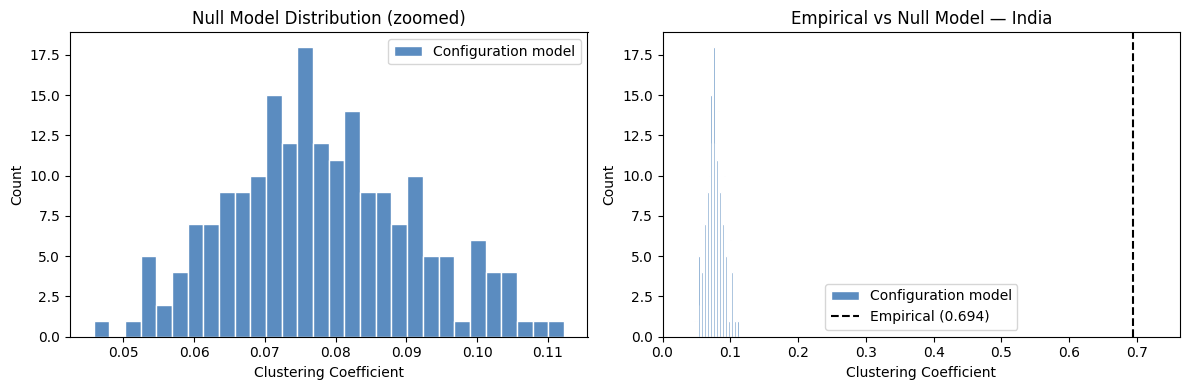

In [11]:
if G.number_of_edges() > 0 and G.number_of_nodes() > 3:
    n_networks     = 200
    degree_sequence = [d for n, d in G.degree()]
    
    ensemble_conf = [
        nx.configuration_model(degree_sequence, create_using=nx.Graph, seed=42+i)
        for i in range(n_networks)
    ]
    
    clustering_empirical = nx.transitivity(G)
    clustering_null      = [nx.transitivity(g) for g in ensemble_conf]
    
    null_mean = np.mean(clustering_null)
    null_std  = np.std(clustering_null)
    zscore    = (clustering_empirical - null_mean) / null_std if null_std > 0 else float("inf")
    
    print(f"Empirical clustering coefficient: {clustering_empirical:.4f}")
    print(f"Null model mean:                  {null_mean:.4f}")
    print(f"Null model std:                   {null_std:.4f}")
    print(f"Z-score:                          {zscore:.2f}")
    print(f"(Full Product Space Z-score:       142.61)")
    print()
    if zscore > 2:
        print("Result: Empirical clustering is significantly above the null model.")
        print("India's subgraph clustering CANNOT be explained by degree sequence alone.")
    else:
        print("Result: Empirical clustering is NOT significantly above the null model.")
        print("India's subgraph clustering may be a byproduct of its degree sequence.")
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].hist(clustering_null, bins=30, color="#5b8cc0", edgecolor="white",
                 label="Configuration model")
    axes[0].set_xlabel("Clustering Coefficient")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Null Model Distribution (zoomed)")
    axes[0].legend()
    
    axes[1].hist(clustering_null, bins=30, color="#5b8cc0", edgecolor="white",
                 label="Configuration model")
    axes[1].axvline(clustering_empirical, color="black", linestyle="--",
                    label=f"Empirical ({clustering_empirical:.3f})")
    full_range = max(clustering_empirical * 1.1, null_mean + 5 * null_std, 0.5)
    axes[1].set_xlim(0, full_range)
    axes[1].set_xlabel("Clustering Coefficient")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Empirical vs Null Model — India")
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig("india_config_model.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Insufficient edges for configuration model test.")


The configuration model test asks: *is the clustering in India's subgraph more than we would expect given just its degree sequence?*

In the full Product Space, the answer was a resounding yes (Z-score = 142.61), confirming that the triangular structure reflects genuine economic mechanisms: countries that export two related products almost always also export a third.

For India, the Z-score tells us whether the same logic applies specifically to India's export basket. A high Z-score (> 2) would mean India's competitive products genuinely cluster into capability triangles evidence that India has coherent productive clusters where capabilities spill over into nearby products.

A low Z-score would be economically concerning: it would suggest India's clustering is an artefact of having a few high-degree hub products, rather than reflecting true capability coherence. This would limit India's ability to diversify into nearby products using existing know-how.

To test whether India's clustering structure reflects genuine economic mechanisms or is merely a byproduct of its degree sequence, we generated an ensemble of 200 random networks using the configuration model — which preserves the exact degree sequence but randomises all connections.
The results are unambiguous:

**Empirical clustering coefficient**: 0.6940, indicating India's subgraph is highly triangulated
**Null model mean**: 0.0780, indicating the null predicts less than a tenth of the observed clustering and 
**Z-score: 47.33** which is about 47 standard deviations above the null model mean

A Z-score of 47 is far beyond any reasonable significance threshold (Z > 2). The null model distribution clusters tightly around 0.078, while the real subgraph sits at 0.694. India's clustering structure cannot be explained by its degree sequence alone. This is the most economically reassuring finding in the analysis. It confirms that India's export capabilities form genuine productive clusters: countries (and sub-national units) that have developed competitiveness in two related Indian export products are far more likely to also produce a third related product than pure chance would predict. The triangular structure of India's subgraph reflects real shared capabilities such as skilled labour in garments, supply chains in textiles, technical knowledge in metal processing which do generate coherent clusters.

However, the Z-score of 47.33 is substantially lower than the full Product Space's 142.61. This gap has a structural explanation: the full Product Space has 774 nodes and 1,779 edges forming a coherent global capability network built over decades; India's subgraph has 273 nodes and only 346 edges spread across 91 disconnected fragments. With fewer edges and more isolation, there are simply fewer triangles to count, and the statistical signal, while highly significant is hence weaker.


---

## 9. Network Visualization

A force-directed visualisation of India's subgraph within the Product Space,
with nodes sized by degree and colored by detected community. We also overlay
India's position on the full Product Space to show where India's exports sit
relative to the global capability network.


<positron-console-cell-12>:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


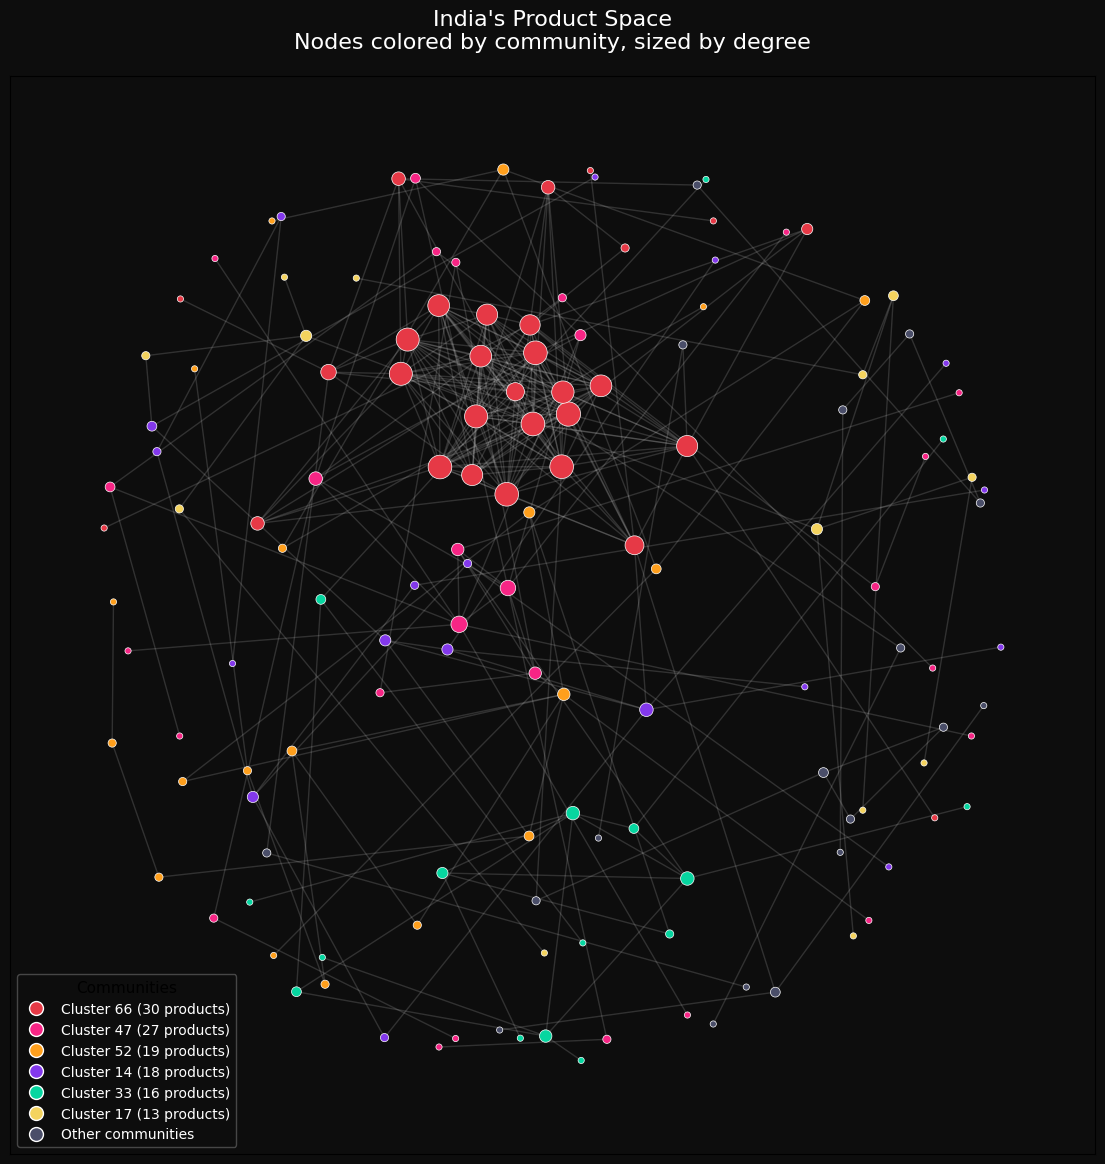

In [12]:
# ── Panel A: India's Subgraph ────────────────────────────────────────────────
def draw_network(G, pos=None, node_colors="#5b8cc0", title="", figsize=14):
    node_min_size    = 5
    node_size_scaling = 15
    degree_sequence  = dict(G.degree())
    
    if pos is None:
        pos = nx.spring_layout(G, seed=42)
    
    node_sizes = [node_min_size + node_size_scaling * degree_sequence[node]
                  for node in G.nodes()]
    
    fig = plt.figure(figsize=(figsize, figsize), facecolor="#0d0d0d")
    ax  = fig.add_subplot(111, facecolor="#0d0d0d")
    nx.draw_networkx_edges(G, pos, alpha=0.15, edge_color="white")
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                           node_color=node_colors,
                           linewidths=0.5, edgecolors="white")
    plt.title(title, fontsize=16, color="white", pad=20)
    return fig, ax

# Largest connected component of India's subgraph
if G.number_of_nodes() > 0:
    largest_cc_nodes = max(nx.connected_components(G), key=len)
    G_lcc = G.subgraph(largest_cc_nodes).copy()
    
    pos_india = nx.spring_layout(G_lcc, k=0.75, iterations=50, seed=42)
    
    # Color by community
    community_map_lcc = nx.get_node_attributes(G_lcc, "community")
    all_comms = sorted(set(community_map_lcc.values()))
    
    # Assign vivid colors to the 6 largest communities
    cmap = plt.cm.get_cmap("tab10", min(len(all_comms), 10))
    comm_sizes   = {c: sum(1 for v in community_map_lcc.values() if v == c)
                    for c in all_comms}
    top_comms    = sorted(comm_sizes, key=comm_sizes.get, reverse=True)
    
    vivid_colors = ["#e63946", "#f72585", "#ff9f1c", "#8338ec",
                    "#06d6a0", "#f4d35e"]
    named_colors  = {comm: vivid_colors[i]
                     for i, comm in enumerate(top_comms[:6])}
    default_color = "#4a4e69"
    
    node_colors_india = [
        named_colors.get(community_map_lcc.get(n, -1), default_color)
        for n in G_lcc.nodes()
    ]
    
    # Build community labels from top products
    comm_labels = {}
    for comm in top_comms[:6]:
        products = [G_lcc.nodes[n].get("name", str(n))
                    for n in G_lcc.nodes() if community_map_lcc.get(n) == comm]
        comm_labels[comm] = f"Cluster {comm+1} ({comm_sizes[comm]} products)"
    
    legend_elements = [
        Line2D([0], [0], marker="o", color="w",
               markerfacecolor=named_colors[c],
               markersize=10, label=comm_labels[c], linestyle="None")
        for c in top_comms[:6]
    ] + [
        Line2D([0], [0], marker="o", color="w",
               markerfacecolor=default_color, markersize=10,
               label="Other communities", linestyle="None")
    ]
    
    fig, ax = draw_network(
        G=G_lcc, pos=pos_india, node_colors=node_colors_india,
        title="India's Product Space\nNodes colored by community, sized by degree"
    )
    ax.legend(handles=legend_elements, loc="lower left", fontsize=10,
              framealpha=0.3, facecolor="#0d0d0d", labelcolor="white",
              title="Communities", title_fontsize=11)
    plt.savefig("india_product_space_network.png", dpi=300,
                bbox_inches="tight", facecolor="#0d0d0d")
    plt.show()


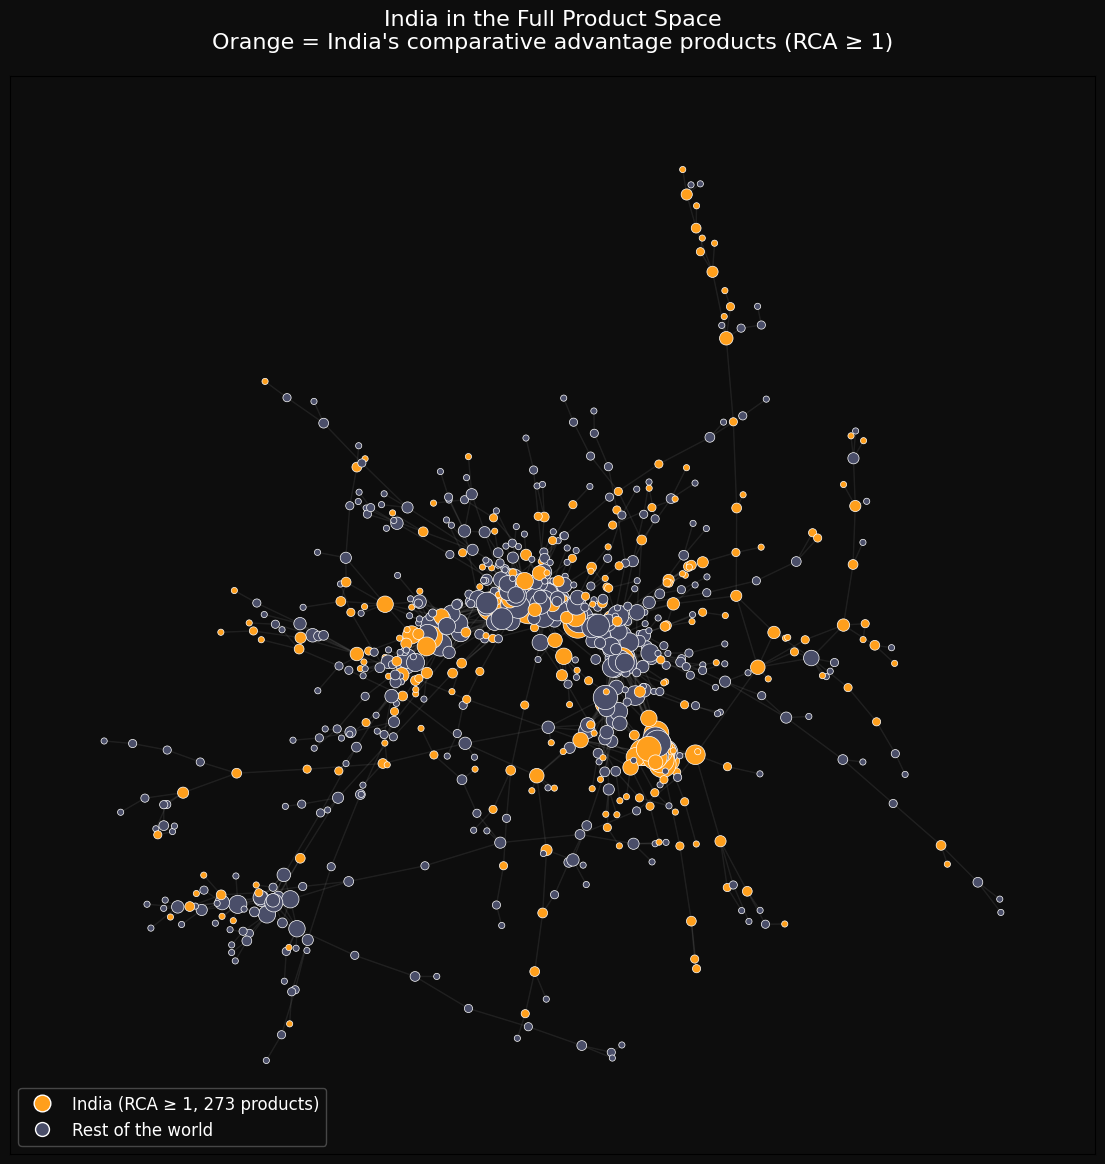

In [13]:
# ── Panel B: India's Position on the Full Product Space ─────────────────────
# Color: orange = India (RCA ≥ 1), slate = rest of the world

G_lcc_full = G_full.subgraph(max(nx.connected_components(G_full), key=len)).copy()
pos_full   = nx.spring_layout(G_lcc_full, k=0.75, iterations=50, seed=42)

india_in_lcc = india_node_ids & set(G_lcc_full.nodes())

node_colors_full = [
    "#ff9f1c" if n in india_in_lcc else "#4a4e69"
    for n in G_lcc_full.nodes()
]
node_sizes_full  = [
    5 + 15 * G_lcc_full.degree(n)
    for n in G_lcc_full.nodes()
]

fig = plt.figure(figsize=(14, 14), facecolor="#0d0d0d")
ax  = fig.add_subplot(111, facecolor="#0d0d0d")

nx.draw_networkx_edges(G_lcc_full, pos_full, alpha=0.08, edge_color="white")
nx.draw_networkx_nodes(G_lcc_full, pos_full,
                       node_size=node_sizes_full,
                       node_color=node_colors_full,
                       linewidths=0.5, edgecolors="white")

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#ff9f1c",
           markersize=12, label=f"India (RCA ≥ 1, {len(india_in_lcc)} products)",
           linestyle="None"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#4a4e69",
           markersize=10, label="Rest of the world", linestyle="None"),
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=12,
          framealpha=0.3, facecolor="#0d0d0d", labelcolor="white")

plt.title("India in the Full Product Space\nOrange = India's comparative advantage products (RCA ≥ 1)",
          fontsize=16, color="white", pad=20)
plt.savefig("india_in_full_product_space.png", dpi=300,
            bbox_inches="tight", facecolor="#0d0d0d")
plt.show()


**Note on Visualisation:**

**Panel A** shows India's subgraph in isolation: only products where India holds RCA ≥ 1, connected by edges from the full Product Space. Nodes are sized by degree and colored by community. The layout reveals whether India's export basket forms a coherent connected structure or a fragmented archipelago.

**Panel B** overlays India's products (orange) on the full Product Space (slate). This is the most informative panel: it shows *where* in the global capability network India's competitive exports sit. India's orange nodes cluster in the industrial core, India is well-positioned for complex diversification.


---

## 10. Conclusion

**India holds RCA ≥ 1 in 273 products, which is 35.3% of the full Product Space, but generates only 19.4% of the edges**. This disproportionality signals the key structural challenge: India's competitive products are spread across distant parts of the capability network with limited interconnection between them.

The **91 connected components** are the most diagnostic feature of this analysis. The full Product Space is essentially one connected network; India's subgraph is an archipelago. The largest component (141 nodes) contains the garment cluster, some chemicals, and the iron/steel community, forming a partial industrial core. The remaining 132 products are scattered across 90 smaller, disconnected fragments with no capability bridges to the rest of India's basket.

The **degree distribution (CV = 1.65, median = 1) confirms extreme heterogeneity**. Most products are nearly isolated nodes, while the garment cluster generates the bulk of the connections. The **high assortativity (0.80)** reflects the tight internal cohesion of that garment core, but equally reflects its disconnection from the rest of the economy.
**Community structure (102 communities, modularity 0.68)** maps onto recognisable sectors: garments and knitwear, iron and steel, industrial machinery, carpets, agricultural staples, gems. The garment community is the largest and densest, while the agricultural and resource communities remain small and peripheral. India does have nascent industrial clusters in machinery and metals, but these are not yet large enough to constitute an integrated industrial core.

Centrality analysis sharpens the picture further. India's degree hubs are finished garments, which are lower-complexity consumer goods, whereas the full Product Space's degree hubs are motor vehicle parts and industrial machinery. India's betweenness bridges are synthetic yarn and iron/steel articles, intermediate inputs that structurally connect the garment core to other communities. These bridge products are strategically important: if India's competitiveness in them were to weaken, the already fragmented subgraph would fracture further.

**The configuration model test (Z = 47.33)** confirms that India's clustering is real and economically meaningful rather than a statistical artefact. Productive capabilities do genuinely cluster in India's export basket. **The challenge is not the absence of clusters but their fragmentation and peripheral position in the global capability network.**

In the framework of Hidalgo et al. (2007), India's development path is shaped by this structure. **The products most accessible for diversification are those adjacent to the existing garment and textile cluster (synthetic fibres, fabric processing, apparel accessories) or adjacent to the iron/steel community (basic machinery, pipe fittings, castings).** Moving into the dense industrial core of the global Product Space, where machinery, chemicals, and electronics interconnect, would require bridging capability gaps that the current export structure does not easily support.

---

## References

Hidalgo, C.A., Klinger, B., Barabási, A.L., & Hausmann, R. (2007). The Product
Space Conditions the Development of Nations. *Science*, 317(5837), 482–487.
https://doi.org/10.1126/science.1144581

Hidalgo, C.A., & Hausmann, R. (2009). The Building Blocks of Economic Complexity.
*PNAS*, 106(26), 10570–10575.
https://doi.org/10.1073/pnas.0900943106

The Growth Lab at Harvard University (2023). The Atlas of Economic Complexity.
https://atlas.cid.harvard.edu
